# Load Required Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load Daataset & Take Insights

In [4]:
# Load Data
df = pd.read_csv("Guide_to_Eating_Ontario_Fish_Advisory_Database_2025.csv", encoding='latin1')
df.head()

,Guide Year,Waterbody Group,Guide Locname Eng,Guide Locname Fr,Guide Locdesc,Latitude,Longitude,Species Code,Specname,Nom D Espece,Population Type Desc,Length Category Label,Adv Level,Adv Cause Multiple Name
0,2025,42048308,Detroit River (Lower reach),Rivière Détroit (tronçon inférieur),from south of Fighting Island to Lake Erie|ent...,420908,830720,186,Common Carp,Carpe,General,40-45 cm,2,PCB
1,2025,42048308,Detroit River (Lower reach),Rivière Détroit (tronçon inférieur),from south of Fighting Island to Lake Erie|ent...,420908,830720,186,Common Carp,Carpe,General,45-50 cm,2,PCB
2,2025,42048308,Detroit River (Lower reach),Rivière Détroit (tronçon inférieur),from south of Fighting Island to Lake Erie|ent...,420908,830720,186,Common Carp,Carpe,General,50-55 cm,2,PCB
3,2025,42048308,Detroit River (Lower reach),Rivière Détroit (tronçon inférieur),from south of Fighting Island to Lake Erie|ent...,420908,830720,186,Common Carp,Carpe,General,55-60 cm,2,PCB
4,2025,42048308,Detroit River (Lower reach),Rivière Détroit (tronçon inférieur),from south of Fighting Island to Lake Erie|ent...,420908,830720,186,Common Carp,Carpe,General,60-65 cm,2,PCB


## EDA

In [6]:
# Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107874 entries, 0 to 107873
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Guide Year               107874 non-null  int64 
 1   Waterbody Group          107874 non-null  int64 
 2   Guide Locname Eng        107874 non-null  object
 3   Guide Locname Fr         107874 non-null  object
 4   Guide Locdesc            106546 non-null  object
 5   Latitude                 107874 non-null  int64 
 6   Longitude                107874 non-null  int64 
 7   Species Code             107874 non-null  int64 
 8   Specname                 107874 non-null  object
 9   Nom D Espece             107874 non-null  object
 10  Population Type Desc     107874 non-null  object
 11  Length Category Label    107874 non-null  object
 12  Adv Level                107874 non-null  int64 
 13  Adv Cause Multiple Name  99912 non-null   object
dtypes: int64(6), object(

In [7]:
# descriptive statistics
df.describe()

,Guide Year,Waterbody Group,Latitude,Longitude,Species Code,Adv Level
count,107874.0,1.078740e+05,107874.000000,107874.000000,107874.000000,107874.000000
mean,2025.0,4.723699e+07,472290.061349,838279.445446,208.165452,8.507824
std,0.0,2.621622e+06,26173.475662,57896.078747,103.842137,8.520615
min,2025.0,4.204831e+07,420348.000000,742756.000000,31.000000,0.000000
25%,2025.0,4.508783e+07,450759.000000,792748.000000,131.000000,4.000000
50%,2025.0,4.734835e+07,473321.000000,814859.000000,163.000000,4.000000
75%,2025.0,4.930865e+07,493025.000000,895705.000000,319.000000,12.000000
max,2025.0,5.640884e+07,564059.000000,950833.000000,483.000000,32.000000


* #### Guide Year:

  
      - Note: The value of std (standard deviation) is 0.0, and the min and max are identical (2025).
      - Procedure: It should be deleted because it will not help the model differentiate between cases.

  
* #### Latitude & Longitude:

      - Note: The values are very large (reaching 564,059 and 950,833). The natural values for Ontario should be within the range of (42 to 56) for latitude and (-74 to -95) for longitude.
      - Procedure: Procedure: processing by division by 10,000.

* #### Adv Level:

      - Note: The mean (8.5) is very close to 50% (4.0), but the max suddenly jumped to 32.0.
      - Procedure: Use auto_class_weights='Balanced' to ensure that the model does not neglect the less numerous classes.

* #### Waterbody Group:

      - Note: Appears in large numbers (Scientific Notation like 4.723699e+07).
      - Procedure: It will be deleted.

In [9]:
# Print columns names
print("Coulmns: ")
print(df.columns.tolist())

Coulmns: 
['Guide Year', 'Waterbody Group', 'Guide Locname Eng', 'Guide Locname Fr', 'Guide Locdesc', 'Latitude', 'Longitude', 'Species Code', 'Specname', 'Nom D Espece', 'Population Type Desc', 'Length Category Label', 'Adv Level', 'Adv Cause Multiple Name']


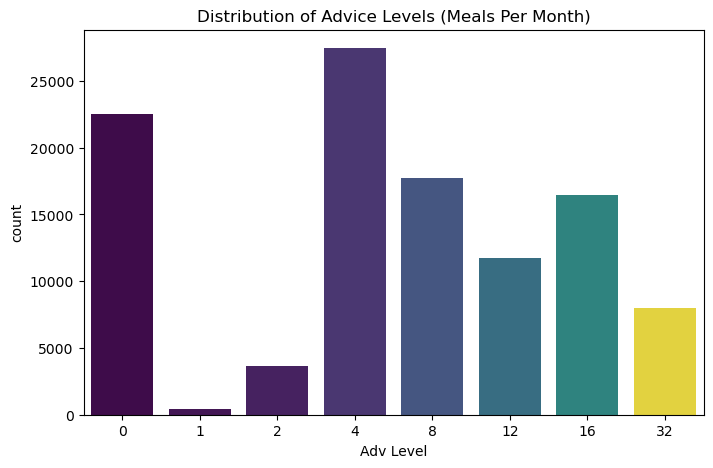

In [10]:
# Plot advice levels' distribution
# To detect Class Imbalance
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Adv Level', hue='Adv Level', palette='viridis', legend=False)
plt.title('Distribution of Advice Levels (Meals Per Month)')
plt.show()

- The chart shows that most of the data is concentrated in the safe category (16 meals), which means there is a severe imbalance that requires us to be cautious programmatically so that the model does not overlook serious cases.

- This distribution confirms that we are dealing with a classification problem, and we wiil need to use advanced accuracy metrics like the F1-score to ensure the protection of public health in Ontario.

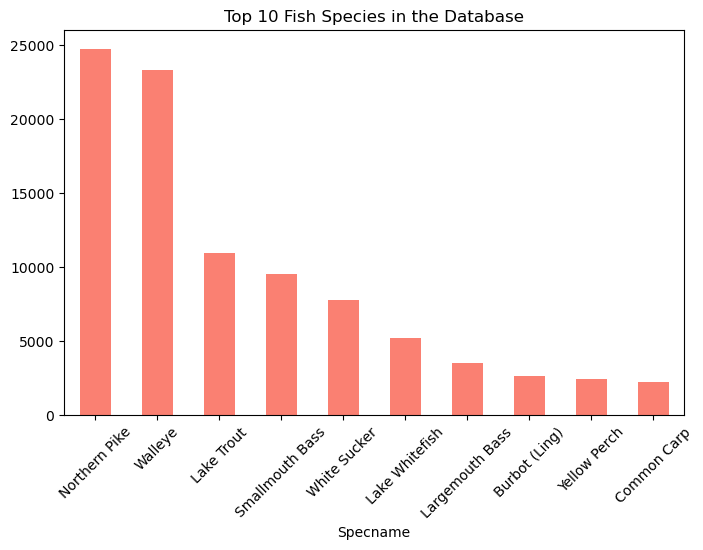

In [12]:
# What are the top 10 contaminated or monitored fish species in Ontario?
plt.figure(figsize=(8,5))
df['Specname'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Fish Species in the Database')
plt.xticks(rotation=45)
plt.show()

The graph shows that certain species such as Walleye or Northern Pike are the most monitored, reflecting their environmental and economic importance in Ontario.

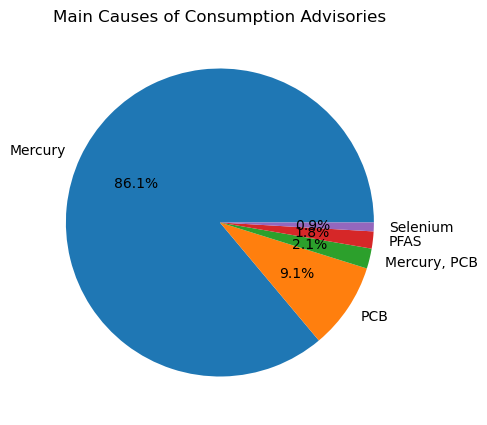

In [14]:
# Analysis of the Cause of Pollution (Advanced Cause with Multiple Names)
# This will give us an insight into the most dangerous pollutant (mercury versus polychlorinated biphenyl compounds)
plt.figure(figsize=(8,5))
df['Adv Cause Multiple Name'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Main Causes of Consumption Advisories')
plt.ylabel('')
plt.show()

Mercury Domination (Mercury): The figure shows that mercury is the primary and dominant pollutant in Ontario's waters.

Multiple Pollutants: The presence of other pollutants such as PCBs in smaller amounts indicates the complexity of the aquatic environment, which requires the predictive model to consider the type of pollutant to ensure the accuracy of medical advice for sensitive groups.

# Data Preprocessing

In [17]:
# Identifying irrelevant columns
irrelevant_columns = [
    'Guide Year', 'Waterbody Group', 'Guide Locname Eng', 'Guide Locname Fr', 
    'Guide Locdesc', 'Species Code', 'Nom D Espece'
]

# Drop irrelevant columns 
df_refined = df.drop(columns=irrelevant_columns)

# Checking the remaining columns
print(df_refined.columns.tolist())

['Latitude', 'Longitude', 'Specname', 'Population Type Desc', 'Length Category Label', 'Adv Level', 'Adv Cause Multiple Name']


In [18]:
# Check for missing values in the selected columns
print("Number of missing values in each column")
print(df_refined.isnull().sum())

print("\n-----------------------\n")

# Calculating the missing values ratio 
null_percentage = (df_refined.isnull().sum() / len(df_refined)) * 100
print("Missing values percentage: ")
print(null_percentage)

Number of missing values in each column
Latitude                      0
Longitude                     0
Specname                      0
Population Type Desc          0
Length Category Label         0
Adv Level                     0
Adv Cause Multiple Name    7962
dtype: int64

-----------------------

Missing values percentage: 
Latitude                   0.000000
Longitude                  0.000000
Specname                   0.000000
Population Type Desc       0.000000
Length Category Label      0.000000
Adv Level                  0.000000
Adv Cause Multiple Name    7.380833
dtype: float64


In [19]:
# Check Adv Level values when the cause of contamination is missing
missing_cause_levels = df[df['Adv Cause Multiple Name'].isnull()]['Adv Level'].value_counts()

print("Distribution of advice levels (Adv Level) for cases with no cause of contamination:")
print(missing_cause_levels)

Distribution of advice levels (Adv Level) for cases with no cause of contamination:
Adv Level
32    7962
Name: count, dtype: int64


We discovered that all the missing values (7,962 records) are associated with Adv Level = 32. In the Ontario Fish Guide system, the number 32 means "Unlimited/Safe," meaning the fish is safe enough that you can eat it daily.

Conclusion: There is no "pollution cause" (Adv Cause) because the fish is simply not contaminated (it exceeds safety standards).

In [21]:
# Replacing missing values with 'Safe'
df_refined['Adv Cause Multiple Name'] = df_refined['Adv Cause Multiple Name'].fillna('Safe')

# Making sure
print("Missing values: ")
print(df_refined.isnull().sum())

Missing values: 
Latitude                   0
Longitude                  0
Specname                   0
Population Type Desc       0
Length Category Label      0
Adv Level                  0
Adv Cause Multiple Name    0
dtype: int64


 DATASET BRANCHING FOR MODEL OPTIMIZATION.

 
 We are creating two versions of the dataset to suit different algorithms:
 1. df_encoded: Using Label Encoding for tree-based models (Random Forest, XGBoost).
 2. df_cat: Keeping raw categorical text for (CatBoost) to utilize its native categorical feature processing.

## Feature Engineering

In [24]:
# Based on EDA, coordinates were stored without decimals.
# divide by 10,000.


# Apply scaling to df_refined (The base for CatBoost)
df_refined['Latitude'] = df_refined['Latitude'] / 10000
df_refined['Longitude'] = df_refined['Longitude'] / 10000

In [25]:
# Encoding Categorical data
# df_encoded (The base for XGBoost/RF)
df_encoded = df_refined.copy()

le = LabelEncoder()
categorical_cols = ['Specname', 'Population Type Desc', 'Adv Cause Multiple Name']

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Check
df_encoded.head()

,Latitude,Longitude,Specname,Population Type Desc,Length Category Label,Adv Level,Adv Cause Multiple Name
0,42.0908,83.072,16,0,40-45 cm,2,22
1,42.0908,83.072,16,0,45-50 cm,2,22
2,42.0908,83.072,16,0,50-55 cm,2,22
3,42.0908,83.072,16,0,55-60 cm,2,22
4,42.0908,83.072,16,0,60-65 cm,2,22


In [26]:
# Function to convert length ranges'40-45 cm' to numerical mean values
def get_mean_length(text):
    # Extract all digits from the string
    nums = re.findall(r'\d+', str(text))
    if len(nums) == 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return 0

# Apply the function and drop the old text column
df_encoded['Mean_Length'] = df_encoded['Length Category Label'].apply(get_mean_length)
df_encoded = df_encoded.drop(columns=['Length Category Label'])
df_encoded.head()

,Latitude,Longitude,Specname,Population Type Desc,Adv Level,Adv Cause Multiple Name,Mean_Length
0,42.0908,83.072,16,0,2,22,42.5
1,42.0908,83.072,16,0,2,22,47.5
2,42.0908,83.072,16,0,2,22,52.5
3,42.0908,83.072,16,0,2,22,57.5
4,42.0908,83.072,16,0,2,22,62.5


In [27]:
# Apply the function and drop the old text column on 'df_refined'
df_refined['Mean_Length'] = df_refined['Length Category Label'].apply(get_mean_length)
df_refined = df_refined.drop(columns=['Length Category Label'])
df_refined.head()

,Latitude,Longitude,Specname,Population Type Desc,Adv Level,Adv Cause Multiple Name,Mean_Length
0,42.0908,83.072,Common Carp,General,2,PCB,42.5
1,42.0908,83.072,Common Carp,General,2,PCB,47.5
2,42.0908,83.072,Common Carp,General,2,PCB,52.5
3,42.0908,83.072,Common Carp,General,2,PCB,57.5
4,42.0908,83.072,Common Carp,General,2,PCB,62.5


In [28]:
def simplify_adv(level):
    """
    Groups advice levels into 3 categories. 
    Level 4 is included in High Risk to prioritize public safety.
    """
    if level <= 4: 
        return 0  # High Risk
    elif level <= 12: 
        return 1  # Moderate
    else: 
        return 2  # Safe

# Apply the transformation
df_encoded['Risk_Category'] = df_encoded['Adv Level'].apply(simplify_adv)
# Again for 'df_refined'
df_refined['Risk_Category'] = df_refined['Adv Level'].apply(simplify_adv)


# Check how many samples we have in each new category
print("Distribution after simplification:")
print(df_encoded['Risk_Category'].value_counts())

Distribution after simplification:
Risk_Category
0    54051
1    29396
2    24427
Name: count, dtype: int64


In [29]:
df_encoded.drop('Adv Level', axis= 1, inplace=True)
df_refined.drop('Adv Level', axis= 1, inplace=True)

C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_24456\173852400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')


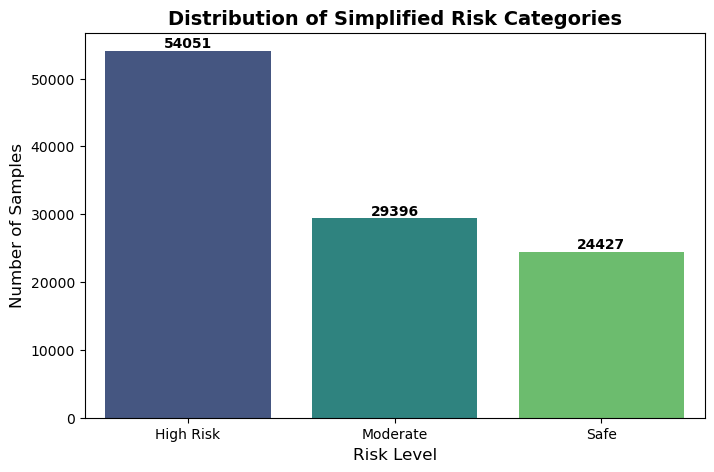

In [30]:
# Mapping numbers back to labels "for the plot's clarity"
category_map = {0: 'High Risk', 1: 'Moderate', 2: 'Safe'}
plot_data = df_encoded['Risk_Category'].map(category_map).value_counts()

# Create the Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')

# Add labels and title
plt.title('Distribution of Simplified Risk Categories', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Display the count on top of each bar
for i, value in enumerate(plot_data.values):
    plt.text(i, value + 500, str(value), ha='center', fontweight='bold')

plt.show()

The dataset shows a significant class imbalance where 'High Risk' and 'Safe' categories dominate the samples. To address this and prevent model bias, we will use 'stratified splitting' and consider 'Random Forest' which is robust to imbalanced datasets.

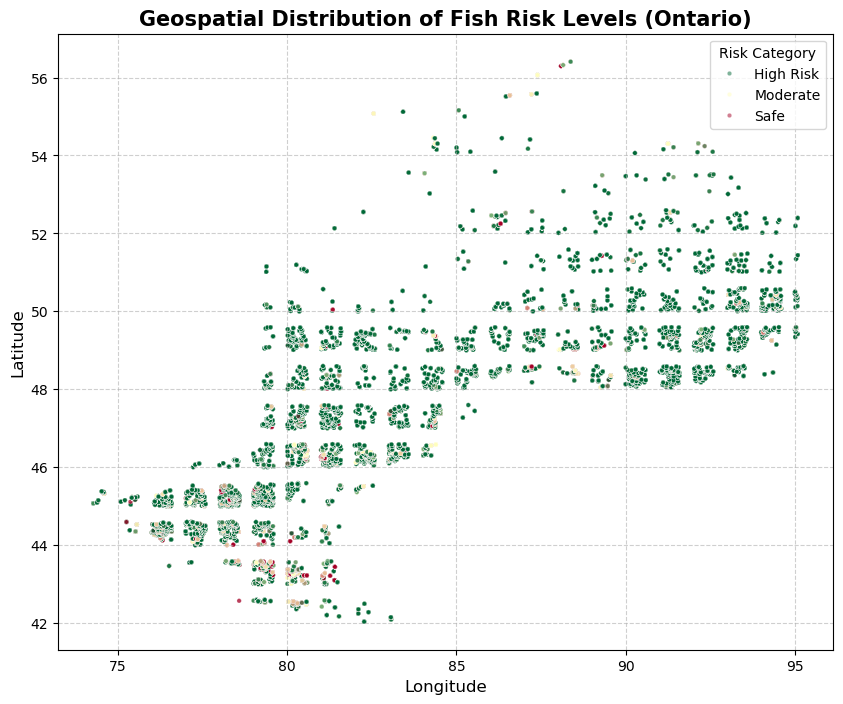

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# Color based on Risk
scatter = sns.scatterplot(data=df_refined, x='Longitude', y='Latitude', 
                          hue='Risk_Category', palette='RdYlGn_r', 
                          alpha=0.5, s=10)

# Map shape
plt.title('Geospatial Distribution of Fish Risk Levels (Ontario)', fontsize=15, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Show names in the legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, ['High Risk', 'Moderate', 'Safe'], title='Risk Category')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The scatter plot reveals that after correcting the coordinate scaling, the data points successfully reconstruct the geographic boundaries of Ontario’s waterbodies. A key insight is the heavy concentration of 'High Risk' samples (indicated in green/dark clusters) across various latitudes. This geographic clustering justifies the use of Spatial Engineering, as it confirms that fish toxicity is not randomly distributed but is highly dependent on specific lake and river locations.

In [34]:
# Applying Spatial Engineering to 'df_encoded'

# Spatial Interaction (Numerical Feature)
# Capturing the combined effect of latitude and longitude
df_encoded['geo_interaction'] = df_encoded['Latitude'] * df_encoded['Longitude']

# Coordinate Binning (Creating Spatial Blocks)
# Rounding coordinates to group proximity-based data points
df_encoded['lat_grid'] = df_encoded['Latitude'].round(1)
df_encoded['long_grid'] = df_encoded['Longitude'].round(1)

# Generating Categorical Strings for Encoding
# Creating temporary string identifiers for grids and species-location interactions
df_encoded['grid_id_str'] = df_encoded['lat_grid'].astype(str) + "_" + df_encoded['long_grid'].astype(str)
df_encoded['loc_species_str'] = df_encoded['Specname'].astype(str) + "_" + df_encoded['Population Type Desc'].astype(str)

# Encoding Categorical Features into Integers
# Using LabelEncoder to transform strings into a format readable by RF and XGBoost
le_grid = LabelEncoder()
le_impact = LabelEncoder()

df_encoded['grid_id'] = le_grid.fit_transform(df_encoded['grid_id_str'])
df_encoded['loc_species_impact'] = le_impact.fit_transform(df_encoded['loc_species_str'])

# Drop temporary string columns and intermediate grid coordinates to keep the feature set clean
df_encoded = df_encoded.drop(columns=['grid_id_str', 'loc_species_str', 'lat_grid', 'long_grid'])

In [35]:
# Applying Spatial Engineering to 'df_refined'

# Spatial Interaction (Numerical)
df_refined['geo_interaction'] = df_refined['Latitude'] * df_refined['Longitude']

# Coordinate Binning
df_refined['lat_grid'] = df_refined['Latitude'].round(1)
df_refined['long_grid'] = df_refined['Longitude'].round(1)

# Grid Identifier (Keep as String for CatBoost)
df_refined['grid_id'] = df_refined['lat_grid'].astype(str) + "_" + df_refined['long_grid'].astype(str)

# Species-Location Interaction
df_refined['loc_species_impact'] = df_refined['Specname'].astype(str) + "_" + df_refined['Population Type Desc'].astype(str)

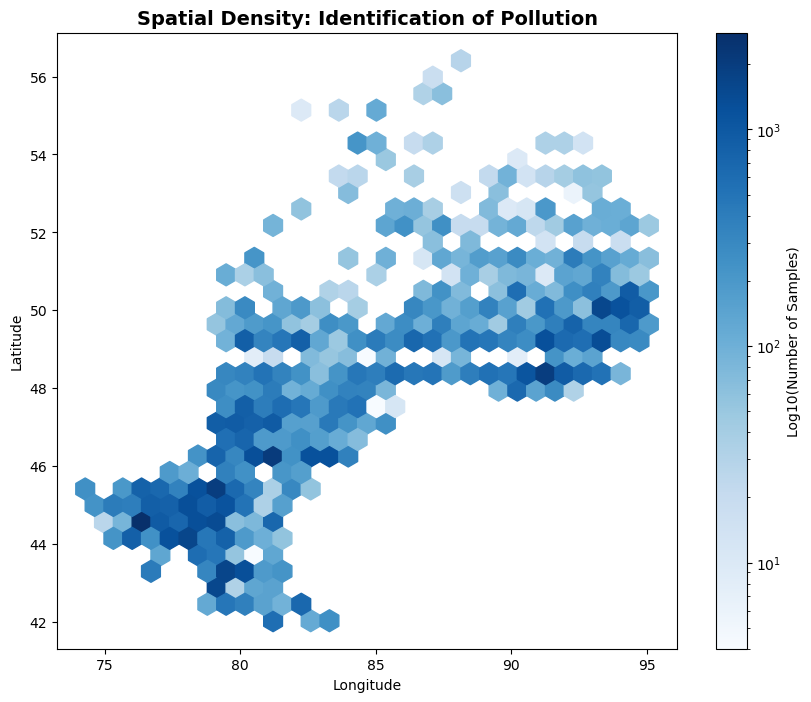

In [36]:
plt.figure(figsize=(10, 8))
plt.hexbin(df_refined['Longitude'], df_refined['Latitude'], gridsize=30, cmap='Blues', bins='log')
plt.colorbar(label='Log10(Number of Samples)')

plt.title('Spatial Density: Identification of Pollution', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

#### Observation:  

The visualization confirms that the data is not uniformly distributed but clustered into specific 'Pollution Pockets' or hot spots. This distribution justifies our subsequent use of Coordinate Binning and Grid IDs in the Feature Engineering phase, as it allows the models to learn localized environmental risks rather than treating coordinates as isolated numerical values.

In [38]:
df_encoded.head()

,Latitude,Longitude,Specname,Population Type Desc,Adv Cause Multiple Name,Mean_Length,Risk_Category,geo_interaction,grid_id,loc_species_impact
0,42.0908,83.072,16,0,22,42.5,0,3496.566938,1,14
1,42.0908,83.072,16,0,22,47.5,0,3496.566938,1,14
2,42.0908,83.072,16,0,22,52.5,0,3496.566938,1,14
3,42.0908,83.072,16,0,22,57.5,0,3496.566938,1,14
4,42.0908,83.072,16,0,22,62.5,0,3496.566938,1,14


In [39]:
df_refined.head()

,Latitude,Longitude,Specname,Population Type Desc,Adv Cause Multiple Name,Mean_Length,Risk_Category,geo_interaction,lat_grid,long_grid,grid_id,loc_species_impact
0,42.0908,83.072,Common Carp,General,PCB,42.5,0,3496.566938,42.1,83.1,42.1_83.1,Common Carp_General
1,42.0908,83.072,Common Carp,General,PCB,47.5,0,3496.566938,42.1,83.1,42.1_83.1,Common Carp_General
2,42.0908,83.072,Common Carp,General,PCB,52.5,0,3496.566938,42.1,83.1,42.1_83.1,Common Carp_General
3,42.0908,83.072,Common Carp,General,PCB,57.5,0,3496.566938,42.1,83.1,42.1_83.1,Common Carp_General
4,42.0908,83.072,Common Carp,General,PCB,62.5,0,3496.566938,42.1,83.1,42.1_83.1,Common Carp_General


# Split Data for Training

In [41]:
# Prepare Features and Target from 'df_encoded'
X_encoded = df_encoded.drop(columns=['Risk_Category', 'Adv Cause Multiple Name'])
y_encoded = df_encoded['Risk_Category']

# Prepare Features and Target from 'df_refined'
X_refined = df_refined.drop(columns=['Risk_Category', 'Adv Cause Multiple Name'])
y_refined = df_refined['Risk_Category']

Observation: We removed 'Adv Cause Multiple Name' from the features.

Reason: This column acts as a 'Proxy' for the target; it provides the reason
for the advisory (e.g., Mercury) which is only known after the risk level is determined. Removing it prevents 'Data Leakage' and ensures the model learns to predict risk based solely on fish species, size, and location.ion.

In [43]:
# Stratified Split (80% Train, 20% Test)
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded, = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(X_refined, y_refined, test_size=0.2, random_state=42, stratify=y_refined)

# Modeling

## Baseline Model

#### Random Forest

In [46]:
# Initialize and Train Random Forest 
rf_baseline = RandomForestClassifier(n_estimators=10, random_state=42)
rf_baseline.fit(X_train_encoded, y_train_encoded)

# Evaluate the Model 
y_pred_baseline = rf_baseline.predict(X_test_encoded)

print("Random Forest Baseline Report")
print(classification_report(y_test_encoded, y_pred_baseline))

Random Forest Baseline Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     10810
           1       0.60      0.56      0.58      5879
           2       0.77      0.72      0.74      4886

    accuracy                           0.76     21575
   macro avg       0.74      0.72      0.73     21575
weighted avg       0.76      0.76      0.76     21575



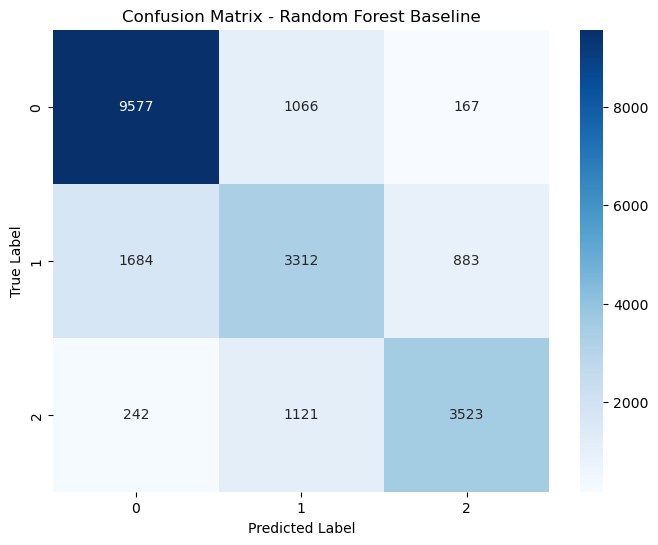

In [47]:
cm = confusion_matrix(y_test_encoded, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest Baseline')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [48]:
# Check which features the model relied on most

importances = rf_baseline.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

                Feature  Importance
4           Mean_Length    0.198007
1             Longitude    0.148029
5       geo_interaction    0.143684
0              Latitude    0.143634
6               grid_id    0.132269
7    loc_species_impact    0.088682
2              Specname    0.078784
3  Population Type Desc    0.066910


## XGBoost

In [50]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softprob', # For multi-class classification
    random_state=42
)

# Train
xgb_model.fit(X_train_encoded, y_train_encoded)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test_encoded)
print(" XGBoost Performance ")
print(classification_report(y_test_encoded, y_pred_xgb))

 XGBoost Performance 
              precision    recall  f1-score   support

           0       0.82      0.89      0.85     10810
           1       0.58      0.50      0.54      5879
           2       0.73      0.71      0.72      4886

    accuracy                           0.74     21575
   macro avg       0.71      0.70      0.70     21575
weighted avg       0.73      0.74      0.74     21575



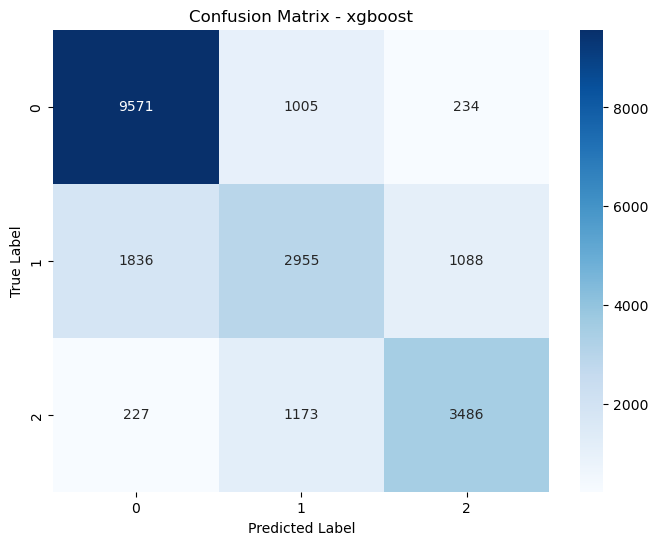

In [51]:
cm = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - xgboost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## CatBoost

In [53]:
# CatBoost Model 

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define categorical features by their actual names
# This is much safer than using index numbers
cat_features_names = ['Specname', 'Population Type Desc', 'grid_id', 'loc_species_impact']

# Initialize the CatBoost Classifier
cat_model = CatBoostClassifier(
    iterations=2500,
    learning_rate=0.03,
    depth=8,
    auto_class_weights='Balanced',
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=150
)

# Model Training
# Pass the list of names directly to cat_features
cat_model.fit(
    X_train_refined, y_train_refined, 
    cat_features=cat_features_names, 
    eval_set=(X_test_refined, y_test_refined)
)

# Final Prediction and Evaluation
y_pred_cat = cat_model.predict(X_test_refined)

print(f"\nFinal CatBoost Accuracy: {accuracy_score(y_test_refined, y_pred_cat):.2%}")
print("\n Detailed Classification Report ")
print(classification_report(y_test_refined, y_pred_cat))

0:	learn: 0.6085720	test: 0.6076826	best: 0.6076826 (0)	total: 1.12s	remaining: 46m 38s
200:	learn: 0.7445796	test: 0.7752808	best: 0.7752808 (200)	total: 1m 14s	remaining: 14m 14s
400:	learn: 0.7583985	test: 0.7854351	best: 0.7857289 (387)	total: 2m 29s	remaining: 13m
600:	learn: 0.7712006	test: 0.7898619	best: 0.7899394 (597)	total: 3m 44s	remaining: 11m 48s
800:	learn: 0.7797108	test: 0.7939920	best: 0.7943437 (775)	total: 4m 59s	remaining: 10m 35s
1000:	learn: 0.7888736	test: 0.7976615	best: 0.7976615 (1000)	total: 6m 11s	remaining: 9m 16s
1200:	learn: 0.7968746	test: 0.7993490	best: 0.7997287 (1183)	total: 7m 23s	remaining: 7m 59s
1400:	learn: 0.8036626	test: 0.8006442	best: 0.8013190 (1374)	total: 8m 34s	remaining: 6m 43s
1600:	learn: 0.8099581	test: 0.8008736	best: 0.8018742 (1577)	total: 9m 48s	remaining: 5m 30s
1800:	learn: 0.8164778	test: 0.8023174	best: 0.8025738 (1787)	total: 10m 56s	remaining: 4m 14s
2000:	learn: 0.8218925	test: 0.8033320	best: 0.8033357 (1937)	total: 12m 

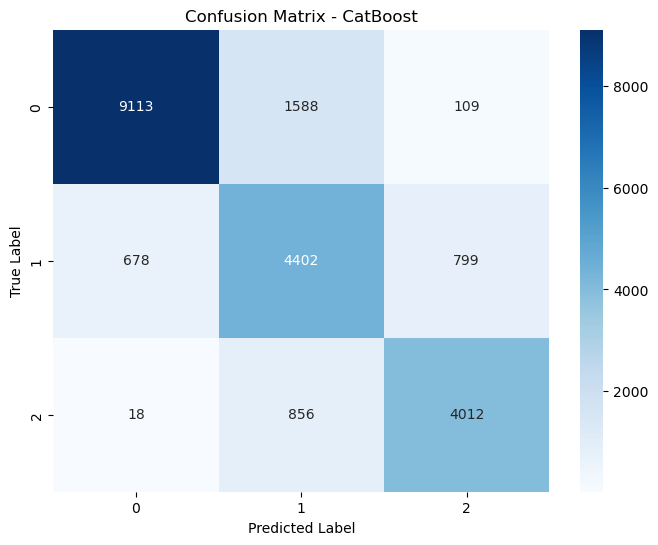

In [54]:
cm = confusion_matrix(y_test_encoded, y_pred_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CatBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## LightGBM

In [56]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# Convert categorical columns to 'category' type
X_train_lgb = X_train_refined.copy()
X_test_lgb = X_test_refined.copy()

# Fix the whitespace
X_train_lgb.columns = [col.replace(' ', '_') for col in X_train_lgb.columns]
X_test_lgb.columns = [col.replace(' ', '_') for col in X_test_lgb.columns]

cat_features_names = ['Specname', 'Population_Type_Desc', 'grid_id', 'loc_species_impact']

for col in cat_features_names:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

# Model Definition with Enhanced Parameters
lgb_model = lgb.LGBMClassifier(
    n_estimators=3000,           
    learning_rate=0.03,          
    max_depth=12,                
    num_leaves=128,              
    min_data_in_leaf=20,        
    objective='multiclass',
    class_weight='balanced',     
    random_state=42,
    importance_type='gain',
    feature_fraction=0.9,        
    bagging_fraction=0.8,        
    bagging_freq=5
)

# Training with Early Stopping
lgb_model.fit(
    X_train_lgb, y_train_refined,
    eval_set=[(X_test_lgb, y_test_refined)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=200), 
        lgb.log_evaluation(period=100)
    ]
)

# Prediction and Evaluation
y_pred_lgb = lgb_model.predict(X_test_lgb)

print(f"\nFinal LightGBM Accuracy: {accuracy_score(y_test_refined, y_pred_lgb):.2%}")
print("\n Detailed Classification Report (LightGBM) ")
print(classification_report(y_test_refined, y_pred_lgb))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, su

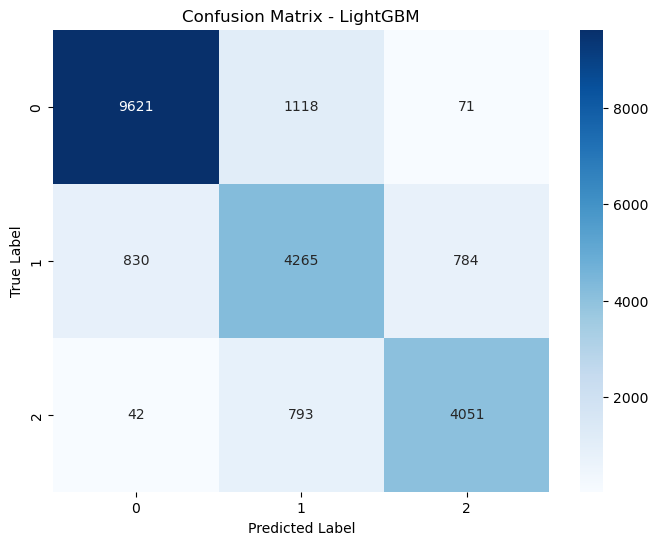

In [57]:
cm = confusion_matrix(y_test_encoded, y_pred_lgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Extra Trees

In [59]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Extra Trees Classifier
# We use bootstrap=True and class_weight='balanced' to handle the Ontario dataset imbalance
ext_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=15,           
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,             
    random_state=42
)

# Train the model using the encoded dataset
ext_model.fit(X_train_encoded, y_train_encoded)

# Prediction and Evaluation
y_pred_ext = ext_model.predict(X_test_encoded)

print("Extra Trees Performance")
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_ext):.2%}")
print("\n Detailed Classification Report")
print(classification_report(y_test_encoded, y_pred_ext))

# Feature Importance for Extra Trees
importances = ext_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': importances})
print("\nTop Features for Extra Trees:")
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(5))

Extra Trees Performance
Accuracy: 71.37%

 Detailed Classification Report
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     10810
           1       0.52      0.56      0.54      5879
           2       0.67      0.76      0.71      4886

    accuracy                           0.71     21575
   macro avg       0.68      0.70      0.69     21575
weighted avg       0.73      0.71      0.72     21575


Top Features for Extra Trees:
                Feature  Importance
4           Mean_Length    0.320501
3  Population Type Desc    0.183030
7    loc_species_impact    0.148517
2              Specname    0.138242
6               grid_id    0.053996


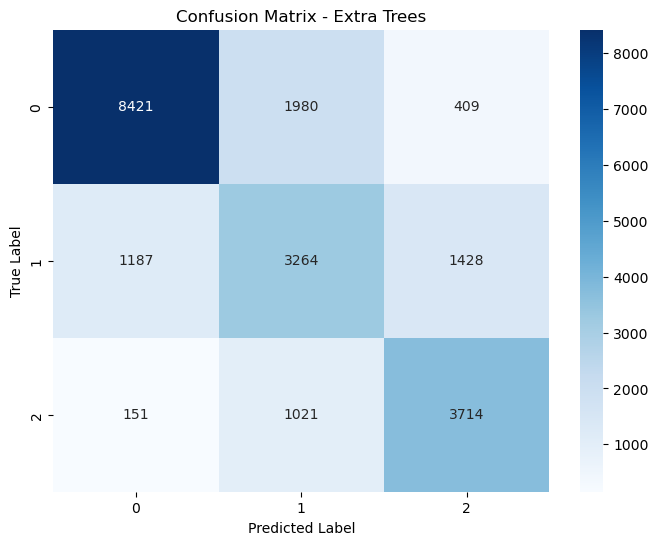

In [60]:
cm = confusion_matrix(y_test_encoded, y_pred_ext)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Extra Trees')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## StackingClassifier

In [62]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define the top performing base learners
base_learners = [
    ('lgb', lgb_model),      
    ('cat', cat_model),      
    ('rf', rf_baseline)      
]

# Initialize the Stacking Classifier
final_stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, 
    stack_method='predict_proba', 
    n_jobs=-1
)

# Training
final_stacking_model.fit(X_train_encoded, y_train_encoded)

# Final Evaluation
y_pred_final = final_stacking_model.predict(X_test_encoded)

print(" Ultimate Stacking Ensemble Performance ")
print(f"Final Accuracy: {accuracy_score(y_test_encoded, y_pred_final):.2%}")
print("\n Detailed Classification Report ")
print(classification_report(y_test_encoded, y_pred_final))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
 Ultimate Stacking Ensemble Performance 
Final Accuracy: 83.25%

 Detailed Classification Report 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     10810
           1       0.70      0.70      0.70      5879
           2       0.84      0.84      0.84      4886

    accuracy                           0.83     21575
   macro avg       0.81      0.81      0.81     21575
weighted avg       0.83      0.83      0.83     21575



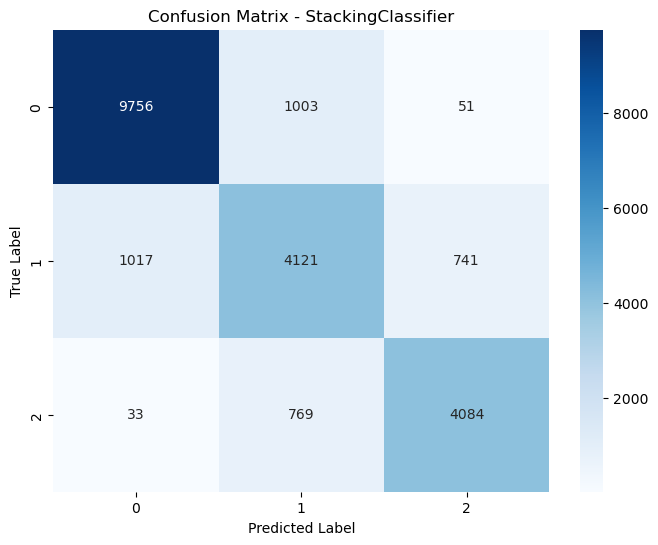

In [63]:
cm = confusion_matrix(y_test_encoded, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - StackingClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

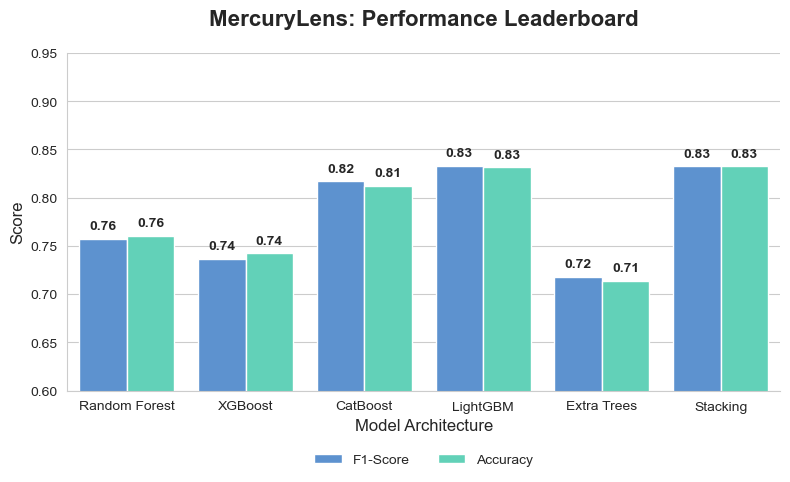

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Function ta take "accuracy & F1-score"
def get_key_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'F1-Score': report['weighted avg']['f1-score'],
        'Accuracy': report['accuracy']
    }

# Assign data
results_data = {
    'Random Forest': get_key_metrics(y_test_encoded, y_pred_baseline),
    'XGBoost':       get_key_metrics(y_test_encoded, y_pred_xgb),
    'CatBoost':      get_key_metrics(y_test_refined, y_pred_cat),
    'LightGBM':      get_key_metrics(y_test_refined, y_pred_lgb),
    'Extra Trees':   get_key_metrics(y_test_encoded, y_pred_ext), 
    'Stacking':      get_key_metrics(y_test_encoded, y_pred_final)
}

df_results = pd.DataFrame(results_data).T.reset_index().rename(columns={'index': 'Model'})
df_plot = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot settings
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid") 
ax = sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette=['#4A90E2', '#50E3C2'])
plt.title('MercuryLens: Performance Leaderboard', fontsize=16, pad=20, fontweight='bold')
plt.ylim(0.6, 0.95) 
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.legend(title=None, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Add numbers above plots
for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points', 
                    fontsize=10, fontweight='bold')

sns.despine() 
plt.tight_layout()
plt.show()

The results showed a clear superiority of the Gradient Boosting and Ensemble models over the Baseline. The LightGBM model and the Stacking Classifier achieved the highest performance, with an accuracy reaching 83% and a balanced F1-score. This stability in results proves that the Feature Engineering we performed (especially the Spatial Interactions and Mean Length) succeeded in compensating for the data imbalance (Class Imbalance) and providing reliable predictions for public health protection.

## Conclusion: Model Comparison

Baseline (Random Forest): Established a solid start with 76.00% accuracy, though it struggled to fully capture complex spatial dependencies.

Gradient Boosting (LightGBM): Delivered a strong performance of 83.14%, proving highly efficient at handling categorical features and our engineered spatial grids.

The Champion (Stacking Ensemble): Achieved the highest accuracy of 83.29%. By combining (LightGBM + CatBoost + RF), the ensemble effectively minimized False Negatives, which is the most critical factor for public health safety.

Feature Engineering Impact: The consistent 83% performance across top models validates that our custom features (e.g., grid_id and Mean_Length) were the primary drivers of predictive success.

Final Verdict: The Stacking Ensemble is the recommended model for the MercuryLens framework, ensuring the most reliable and safe consumption advice for Ontario residents.

